# Ejercicio 5 — Viajes en el TUP de Rosario

El set de datos `viajes_tup.xlsx` contiene información sobre el número de viajes mensuales registrados en el Transporte Urbano de Pasajeros (TUP) de la ciudad de Rosario entre los años 2015 y 2021.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='ticks')

data_viajes = pd.read_excel('../Datasets/viajes_tup.xlsx')
data_viajes['año'] = data_viajes['periodo'].dt.year
data_viajes['mes'] = data_viajes['periodo'].dt.month
data_viajes.head()

,periodo,validaciones_totales,año,mes
0,2015-01-01,8325035,2015,1
1,2015-02-01,8472410,2015,2
2,2015-03-01,10486899,2015,3
3,2015-04-01,11865691,2015,4
4,2015-05-01,11568866,2015,5


## Ítem 1 — Total de viajes por año

> **Realice una tabla que resuma el total de viajes realizados por año y represente gráficamente dicha información. ¿Cuál fue el año en el que se registró la mayor cantidad de viajes en el TUP?**

In [2]:
viajes_anuales = (data_viajes.groupby('año')['validaciones_totales']
                  .sum()
                  .reset_index(name='Total de validaciones'))

print('Total de validaciones por año:')
display(viajes_anuales.style.format({'Total de validaciones': '{:,.0f}'}))

print(f"\nAño con mayor cantidad de viajes: {viajes_anuales.loc[viajes_anuales['Total de validaciones'].idxmax(), 'año']}")

Total de validaciones por año:


,año,Total de validaciones
0,2015,"130,867,042"
1,2016,"134,931,801"
2,2017,"135,495,961"
3,2018,"127,581,349"
4,2019,"117,025,617"
5,2020,"38,096,306"
6,2021,"65,240,461"



Año con mayor cantidad de viajes: 2017


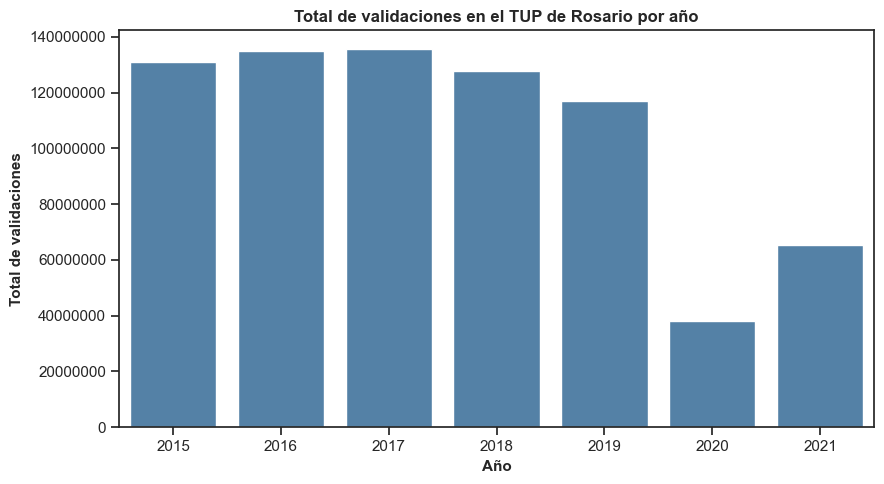

In [3]:
plt.figure(figsize=(9, 5))
sns.barplot(x='año', y='Total de validaciones', data=viajes_anuales,
            color='steelblue', edgecolor='white')
plt.xlabel('Año', fontweight='bold', fontsize=11)
plt.ylabel('Total de validaciones', fontweight='bold', fontsize=11)
plt.title('Total de validaciones en el TUP de Rosario por año', fontweight='bold')
plt.ticklabel_format(axis='y', style='plain')
plt.tight_layout()
plt.show()

## Ítem 2 — Evolución mensual en 2019 y 2020

> **Construya un gráfico en el que se represente la evolución del número de viajes registrados en el TUP a lo largo de los meses para los años 2019 y 2020. Comente brevemente lo observado.**

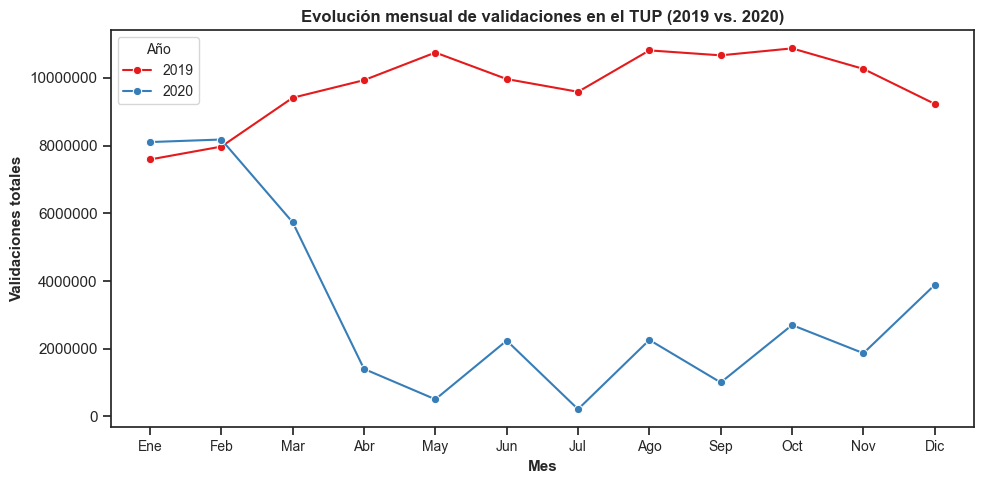

In [4]:
df_19_20 = data_viajes[data_viajes['año'].isin([2019, 2020])].copy()

meses_es = {1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr', 5: 'May', 6: 'Jun',
            7: 'Jul', 8: 'Ago', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dic'}

plt.figure(figsize=(10, 5))
sns.lineplot(x='mes', y='validaciones_totales', hue='año',
             data=df_19_20, marker='o', palette='Set1')
plt.xlabel('Mes', fontweight='bold', fontsize=11)
plt.ylabel('Validaciones totales', fontweight='bold', fontsize=11)
plt.title('Evolución mensual de validaciones en el TUP (2019 vs. 2020)',
          fontweight='bold')
plt.xticks(ticks=range(1, 13), labels=list(meses_es.values()), fontsize=10)
plt.legend(title='Año', fontsize=10, title_fontsize=10)
plt.ticklabel_format(axis='y', style='plain')
plt.tight_layout()
plt.show()

**Observación:** En 2019 el número de validaciones se mantuvo relativamente estable a lo largo del año, con los valores más bajos en enero y febrero (vacaciones de verano) y picos en los meses de mayor actividad escolar y laboral. En 2020 la caída es abrupta a partir de marzo, cuando comenzó el ASPO (Aislamiento Social, Preventivo y Obligatorio) por la pandemia de COVID-19. A partir de mayo se observa una recuperación gradual, pero sin alcanzar en ningún mes los niveles de 2019.